# Explainable AI for Credit Risk Prediction using Machine Learning



# Introduction

Credit risk assessment is essential for financial institutions to determine whether a borrower can repay a loan. Inaccurate predictions can lead to financial losses or unfair rejection of applicants. Traditional models often fail to capture complex patterns in modern financial data, reducing their effectiveness. This project addresses this issue by applying machine learning models and Explainable AI techniques to improve prediction accuracy while ensuring transparency in decision-making

# Problem Statement

Currently, traditional credit scoring methods fail to accurately predict loan risk in financial institutions, affecting both lenders and borrowers. This occurs in credit evaluation systems where linear models cannot capture complex patterns in financial data. This happens because traditional models rely on simple assumptions and lack the ability to handle non-linear relationships, leading to inaccurate decisions and potential financial losses. Hence, there is a need to address this problem

#Objective
##Main Objective:

To develop a machine learning-based system for predicting credit risk and analyzing model performance.

##Sub-Objectives:
To preprocess and prepare the credit dataset for analysis.

To analyze key factors influencing credit risk.

To train and compare traditional and machine learning models for prediction.

To evaluate model performance using appropriate metrics.

To interpret model predictions using Explainable AI techniques

#Proposed Solution
Collect and prepare credit-related data for analysis.

Perform data preprocessing and exploratory data analysis to understand patterns.

Apply machine learning techniques to model and predict credit risk.

Compare model performance to identify the most effective approach.

Use Explainable AI methods to interpret predictions and improve transparency

#Methodology
1. Data Collection

Credit risk dataset containing applicant details such as age, income, loan amount, duration, and credit history.

2. Data Preprocessing

Handle missing values, encode categorical variables, and scale numerical features.

3. Exploratory Data Analysis (EDA)

Analyze data distribution and relationships between features and credit risk.

4. Model Development

Train machine learning models such as Logistic Regression, Decision Tree, and XGBoost.

5. Model Evaluation

Evaluate model performance using metrics like accuracy, confusion matrix, and ROC-AUC.

6. Model Comparison

Compare performance of models to identify the best-performing approach.

7. Explainability

Apply Explainable AI techniques (SHAP) to interpret model predictions and identify key influencing factors.

8. Prediction

Use the best model to predict credit risk for new inputs.

#Data Requirements
Data Type: Structured data

Input Features:

Age

Income

Loan Amount

Loan Duration

Employment Status

Credit History

Marital Status

##Dependents
Target Variable: Credit Risk (Default / Non-default)

Data Size: Moderate-sized dataset (around 1000 records or more)

Data Format: CSV / Excel

Data Quality: Minimal missing values, consistent formatting, and accurate financial records
#Data Collection
The dataset is collected from UCI Machine Learning Repository.

The data is downloaded in CSV format.

The dataset contains historical records of loan applicants and their credit status.

Only publicly available and non-sensitive data is used for analysis.

The collected data is stored locally for preprocessing and model development.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/DataScience/Assignments/Assignment-1-algorithms/Datasets/german.data",sep=' ',header=None)

In [3]:
df

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,1
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,1
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,1
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,2


In [4]:
df[1:2]

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2


In [5]:
columns = [
    "checking_account", "duration", "credit_history", "purpose",
    "credit_amount", "savings", "employment", "installment_rate",
    "personal_status", "other_debtors", "residence_since",
    "property", "age", "other_installment_plans", "housing",
    "existing_credits", "job", "people_liable",
    "telephone", "foreign_worker", "target"
]

df.columns = columns
df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [6]:
df["residence_since"].unique()

array([4, 2, 3, 1])

In [7]:
df.shape


(1000, 21)

In [8]:
df.isnull().sum()

,0
checking_account,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings,0
employment,0
installment_rate,0
personal_status,0
other_debtors,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account         1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment               1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status          1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [11]:
df.describe()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,people_liable,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [12]:
df.describe(include=object)

,checking_account,credit_history,purpose,savings,employment,personal_status,other_debtors,property,other_installment_plans,housing,job,telephone,foreign_worker
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,4,5,10,5,5,4,3,4,3,3,4,2,2
top,A14,A32,A43,A61,A73,A93,A101,A123,A143,A152,A173,A191,A201
freq,394,530,280,603,339,548,907,332,814,713,630,596,963


In [13]:
df.memory_usage()

,0
Index,132
checking_account,8000
duration,8000
credit_history,8000
purpose,8000
credit_amount,8000
savings,8000
employment,8000
installment_rate,8000
personal_status,8000


The checking_account feature shows an uneven distribution, with category A14 having the highest frequency and A13 the lowest

In [14]:
num_cols = df.select_dtypes(include=['int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols

(Index(['duration', 'credit_amount', 'installment_rate', 'residence_since',
        'age', 'existing_credits', 'people_liable', 'target'],
       dtype='object'),
 Index(['checking_account', 'credit_history', 'purpose', 'savings',
        'employment', 'personal_status', 'other_debtors', 'property',
        'other_installment_plans', 'housing', 'job', 'telephone',
        'foreign_worker'],
       dtype='object'))

In [15]:
df["target"].value_counts()

,count
target,
1,700
2,300


Dataset is imbalanced

<Axes: xlabel='target'>

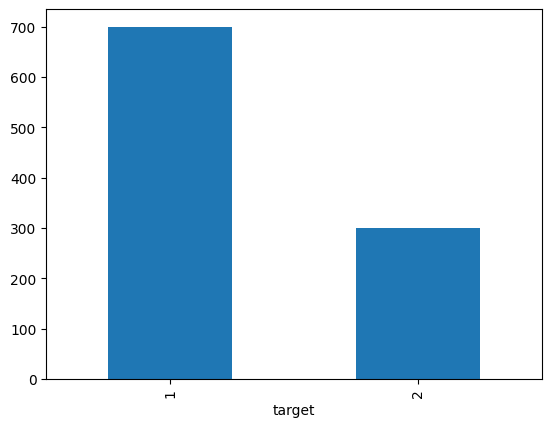

In [16]:
df["target"].value_counts().plot(kind="bar")

In [17]:
df["checking_account"].value_counts()

,count
checking_account,
A14,394
A11,274
A12,269
A13,63


#Univariate Analysis

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

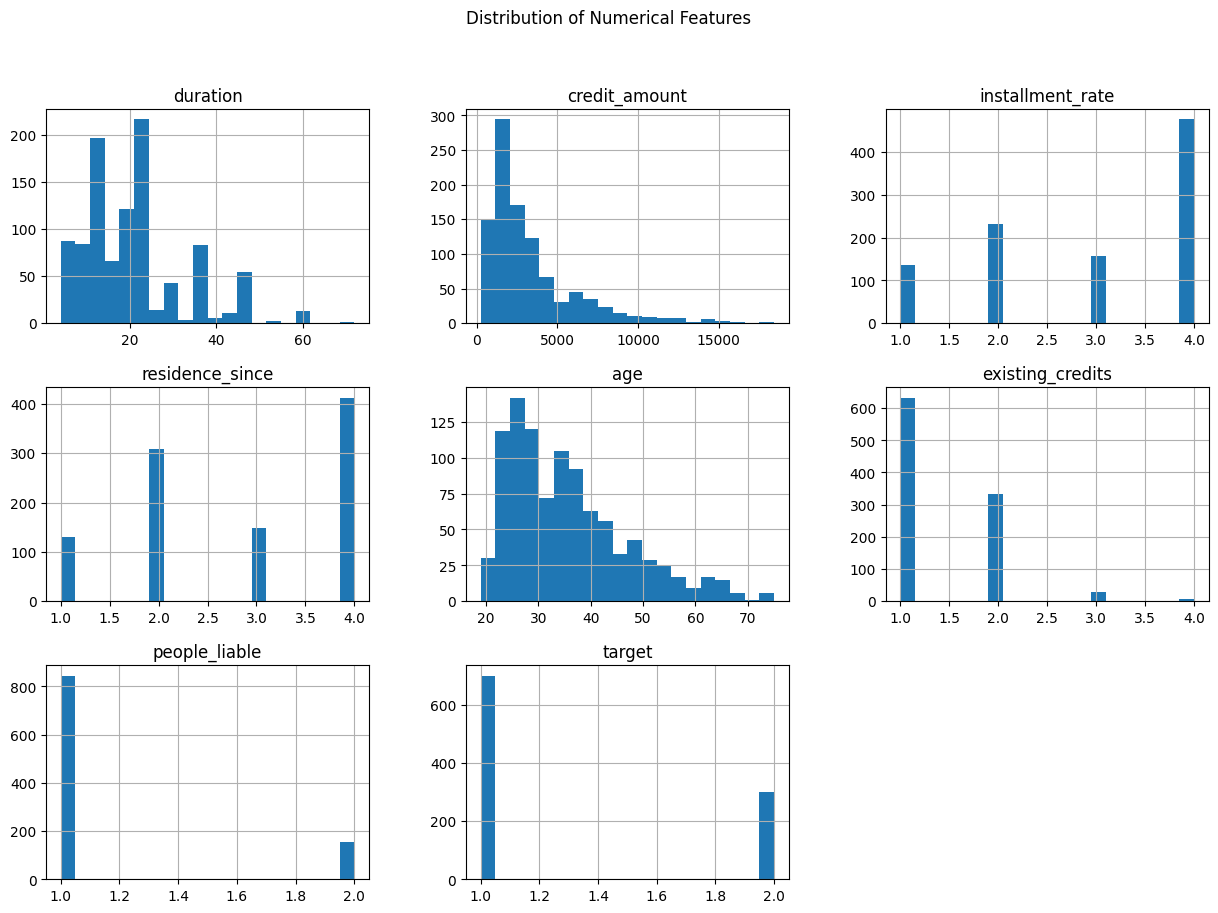

In [19]:
df[num_cols].hist(figsize=(15,10), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.show()

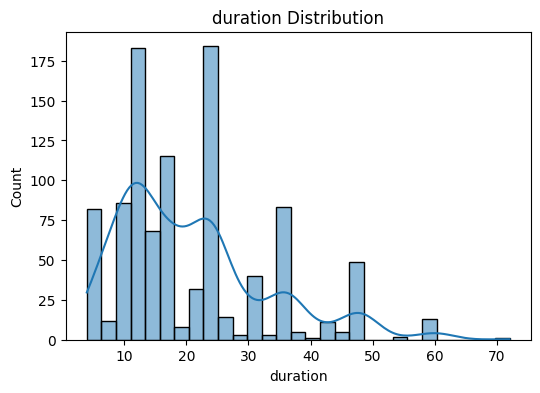

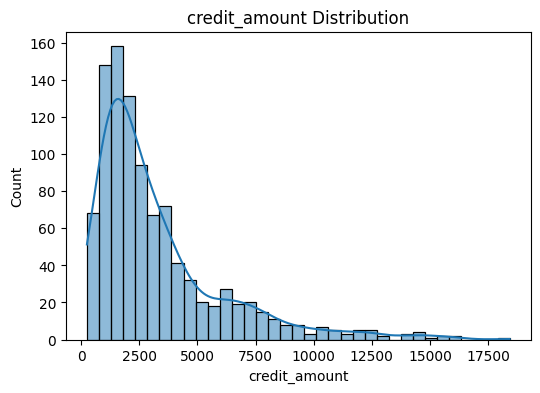

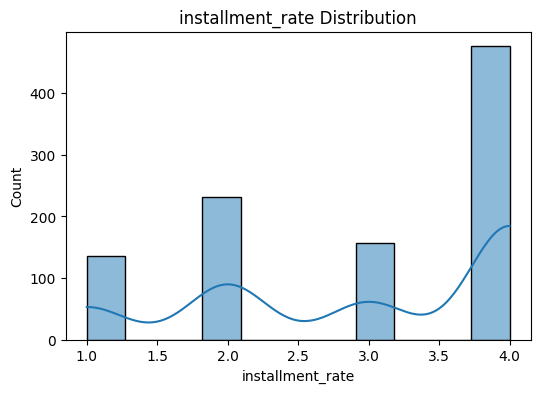

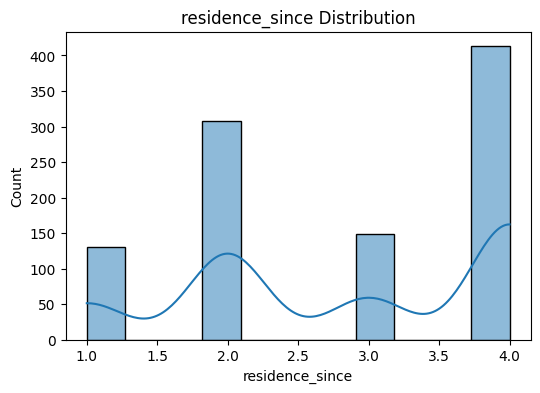

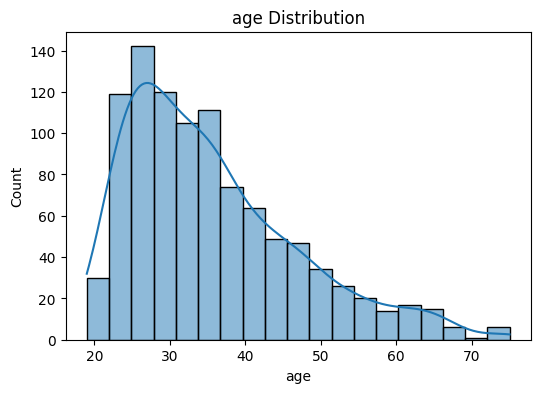

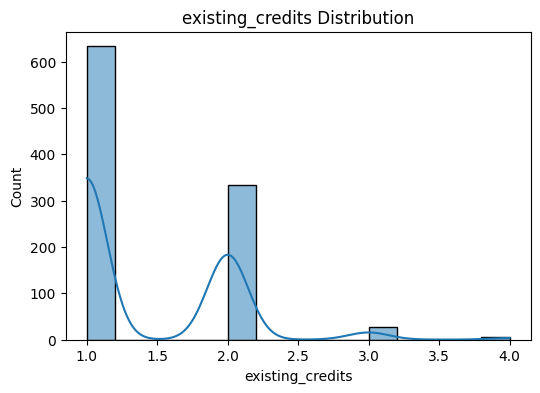

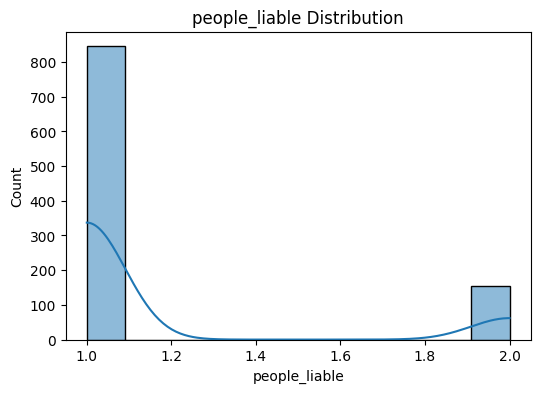

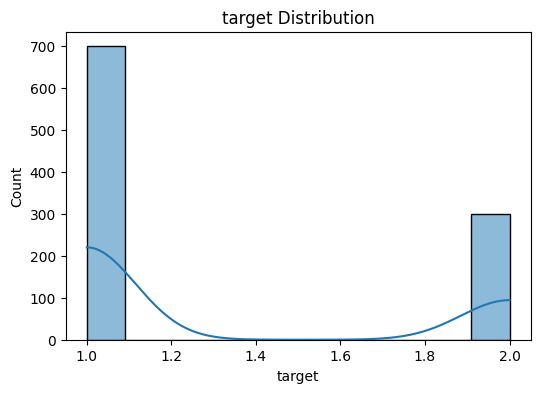

In [20]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

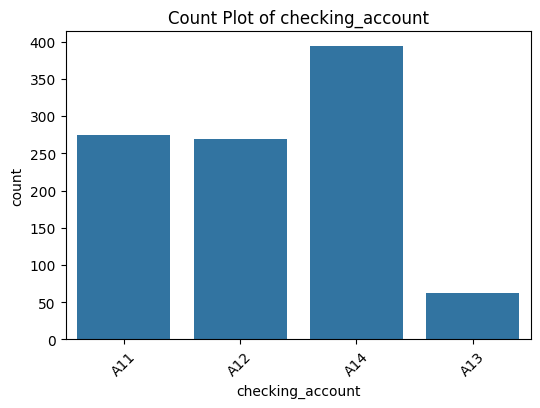

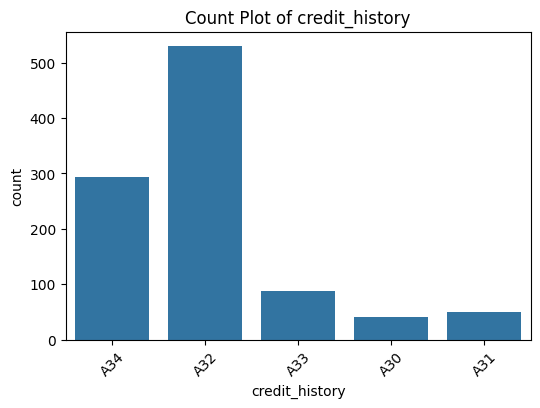

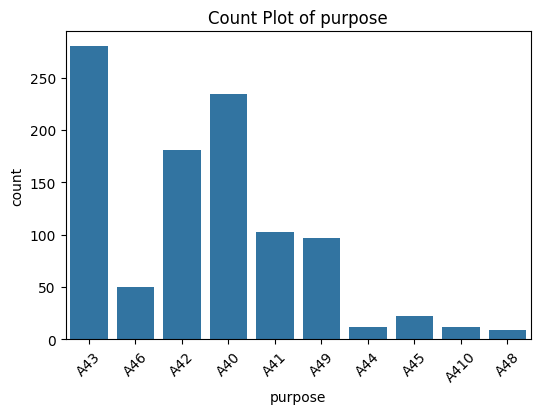

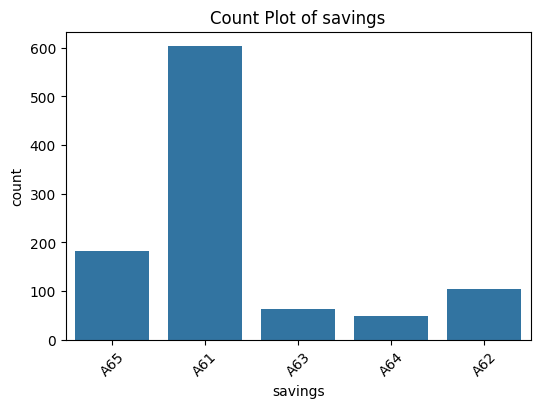

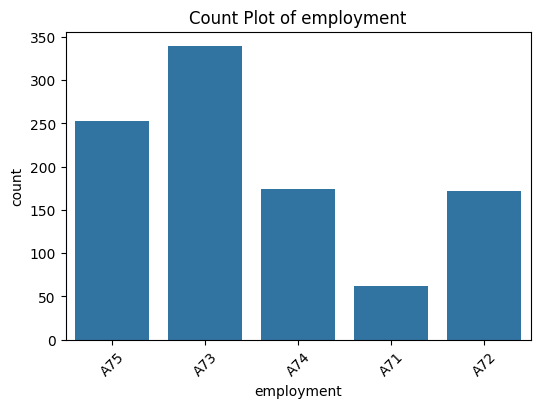

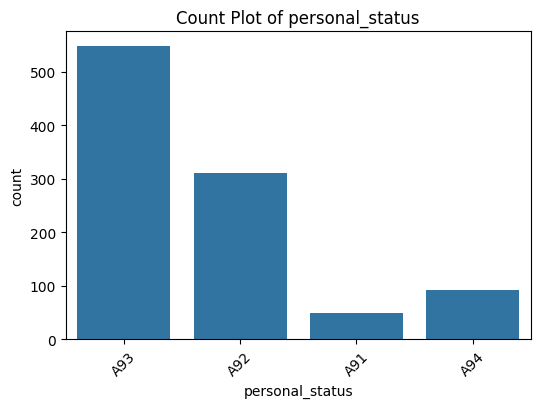

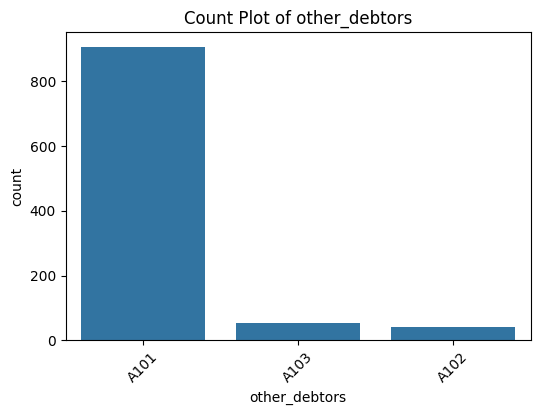

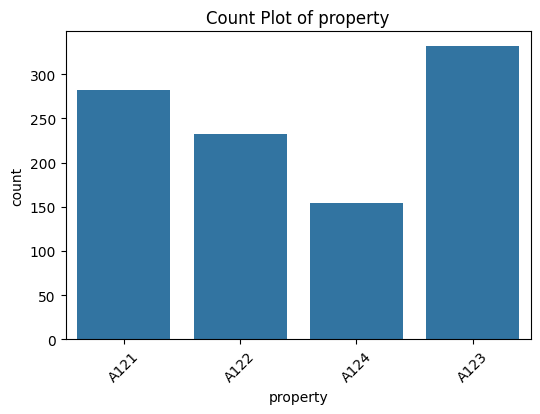

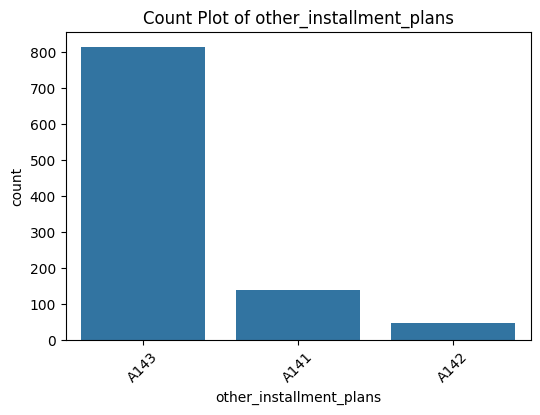

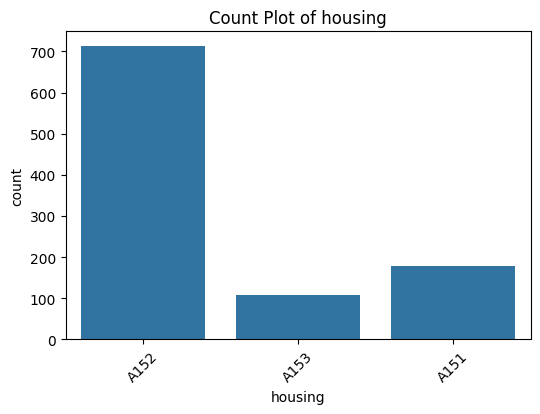

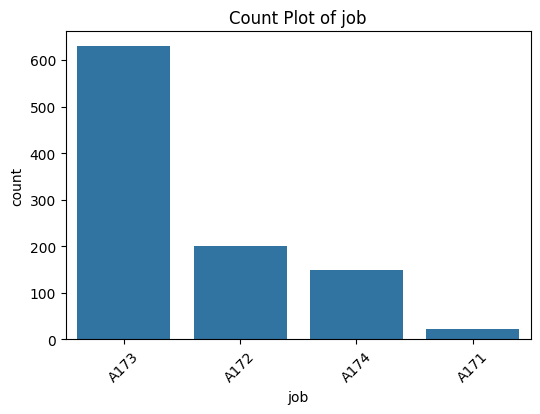

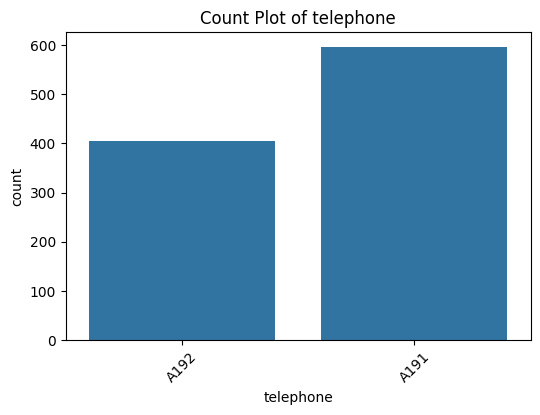

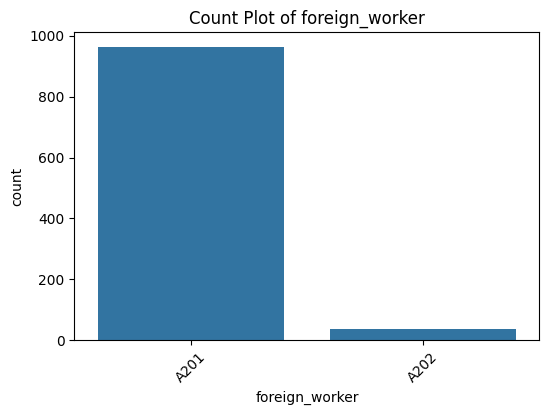

In [21]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

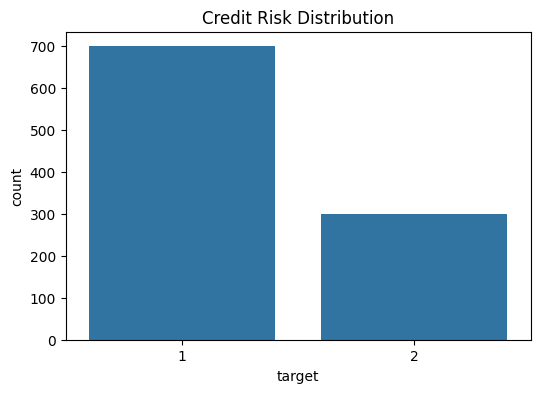

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title("Credit Risk Distribution")
plt.show()

#Bivariate Analysis

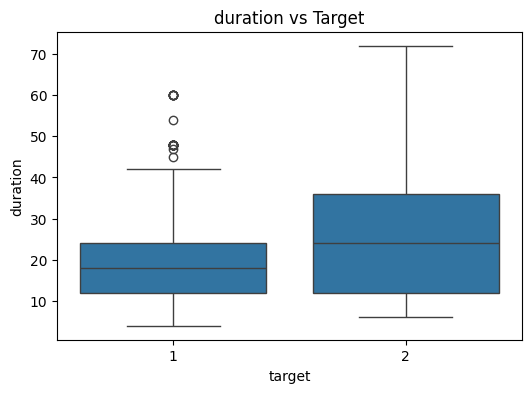

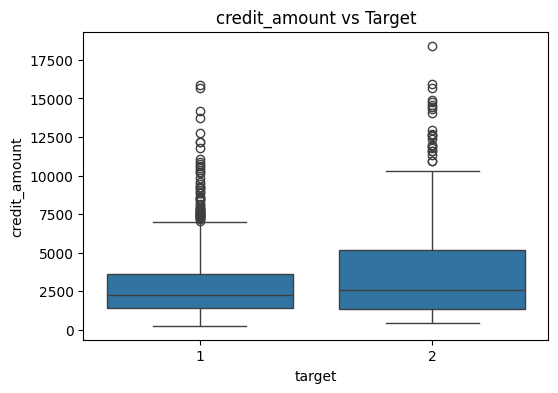

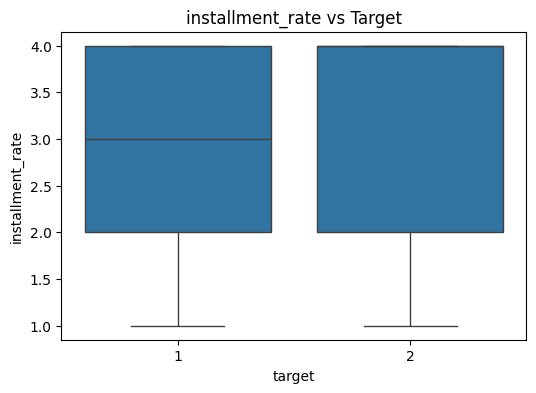

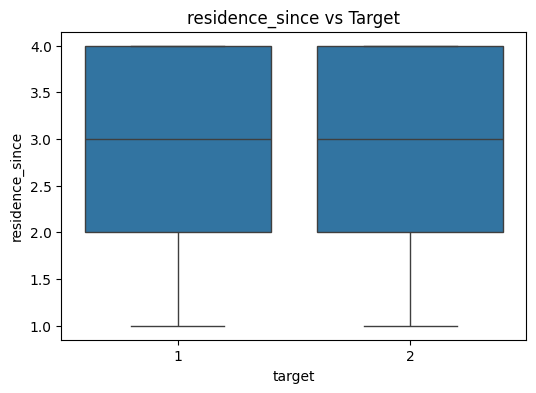

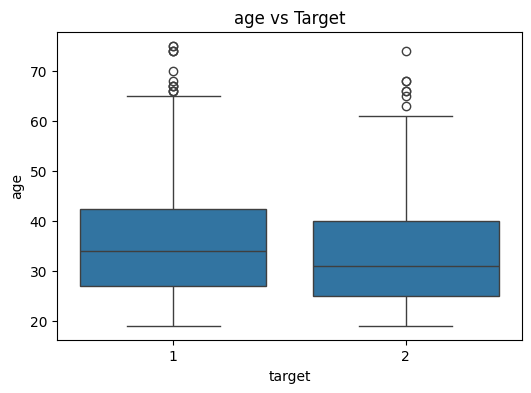

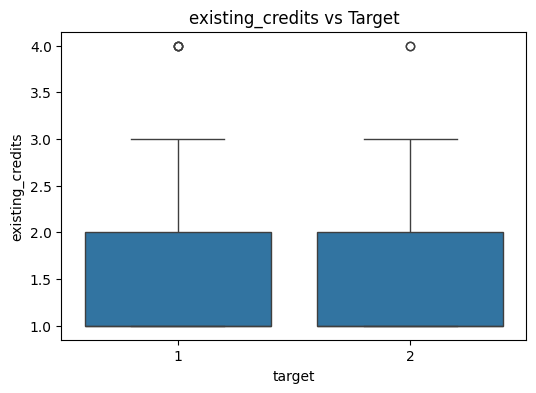

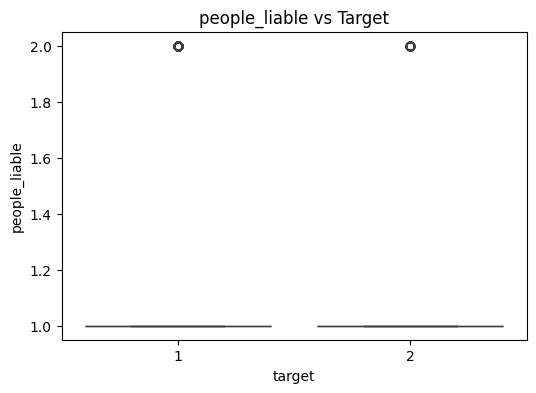

In [23]:
for col in num_cols:
    if col != 'target':
        plt.figure(figsize=(6,4))
        sns.boxplot(x='target', y=col, data=df)
        plt.title(f"{col} vs Target")
        plt.show()

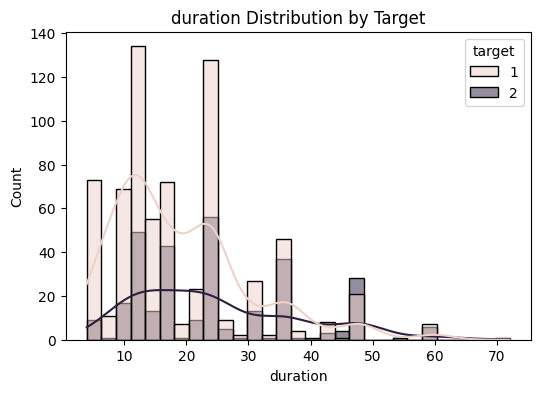

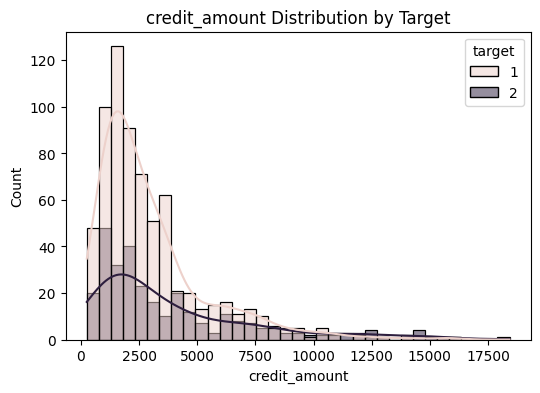

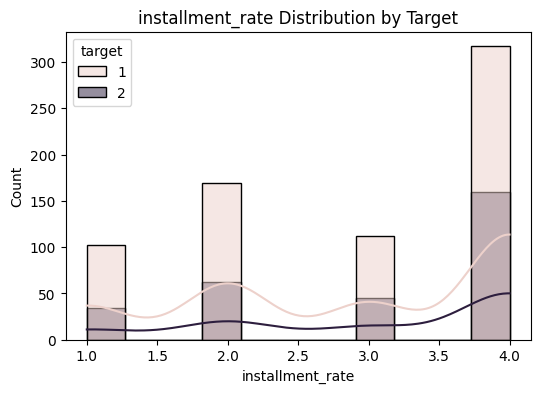

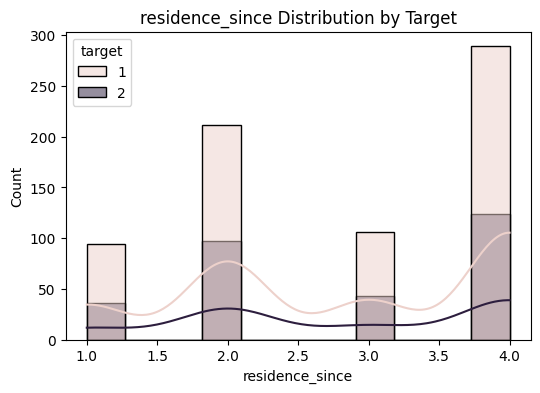

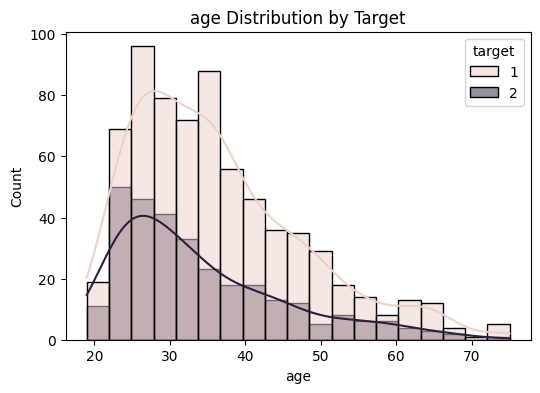

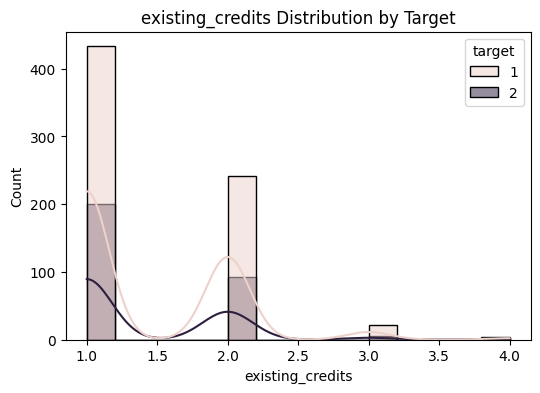

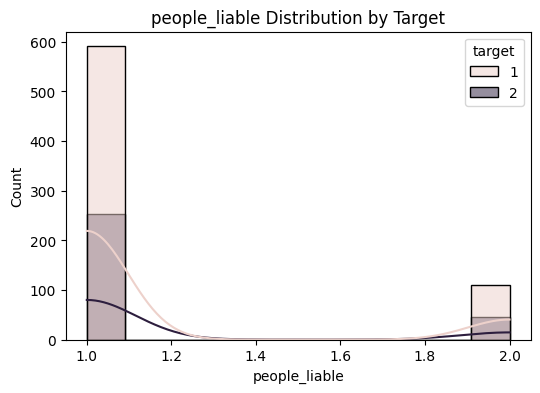

In [24]:
for col in num_cols:
    if col != 'target':
        plt.figure(figsize=(6,4))
        sns.histplot(data=df, x=col, hue='target', kde=True)
        plt.title(f"{col} Distribution by Target")
        plt.show()

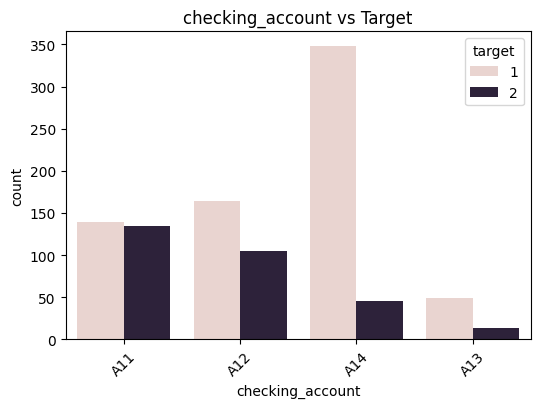

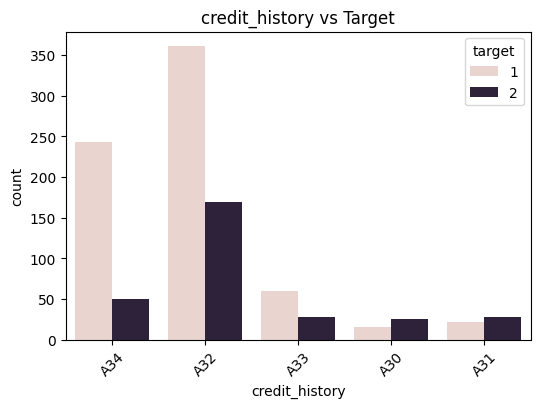

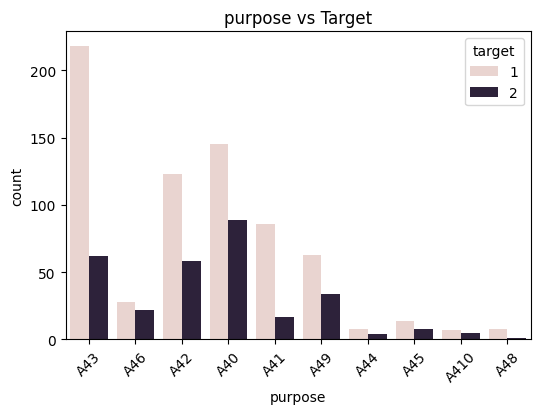

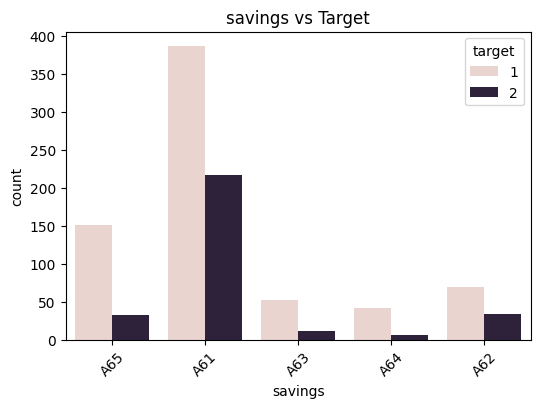

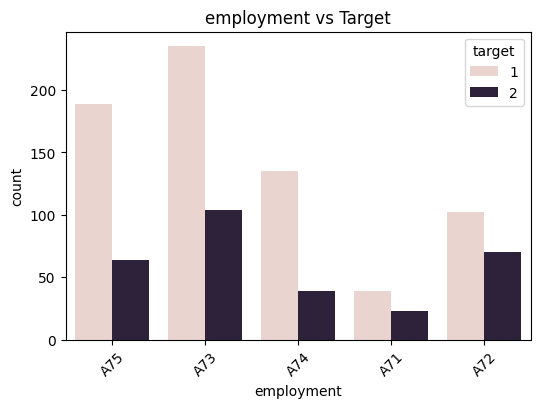

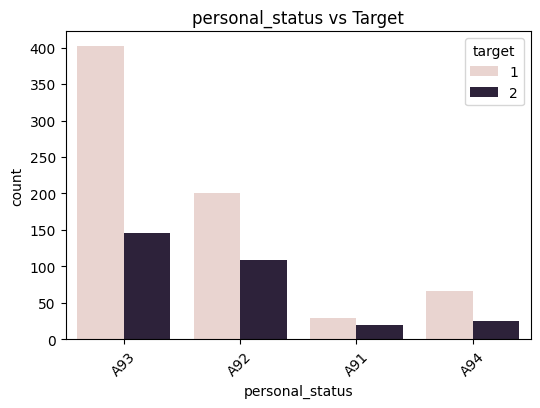

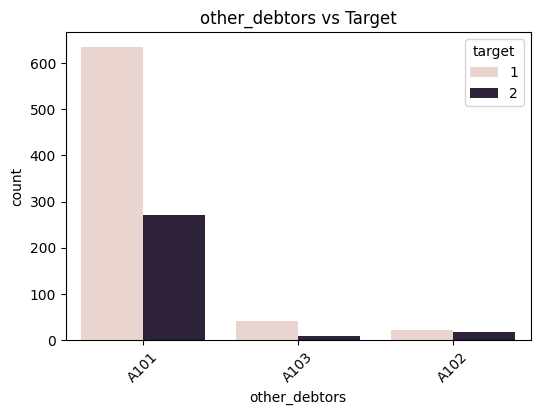

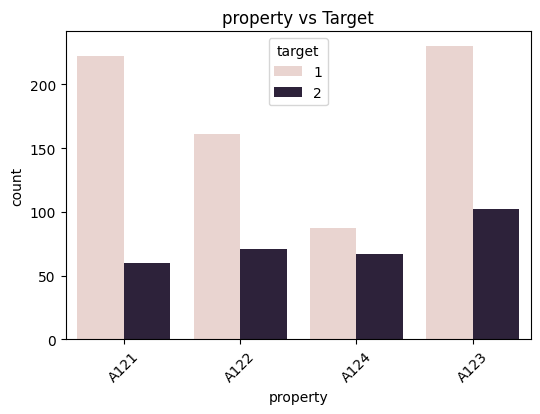

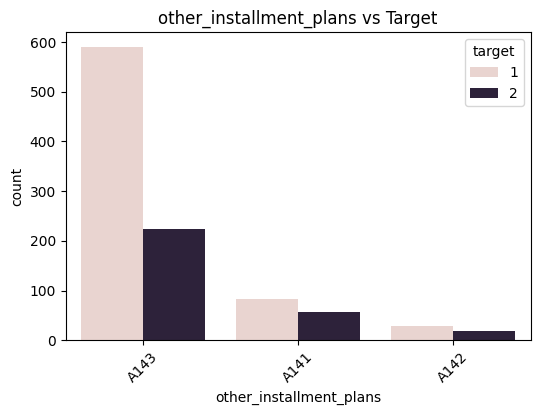

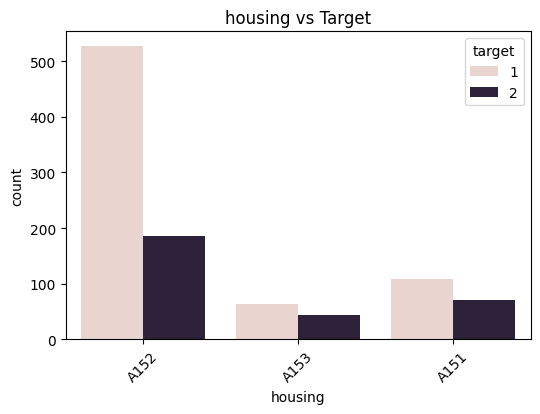

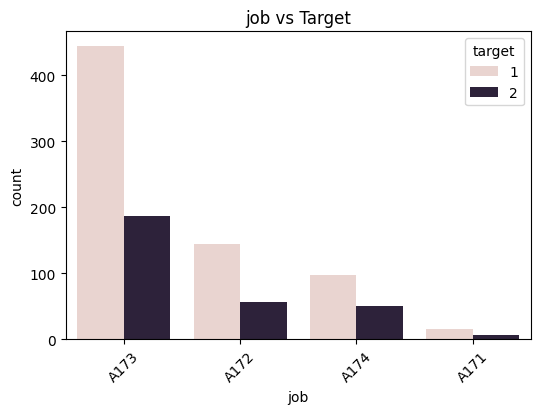

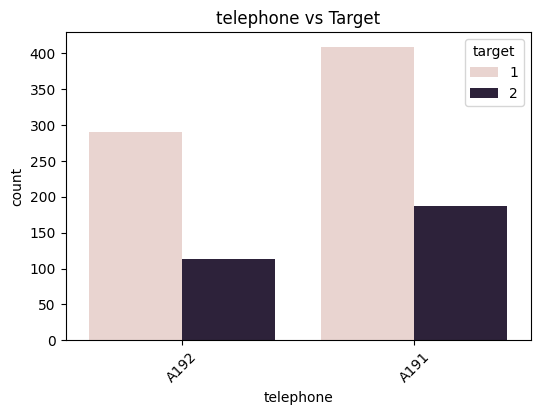

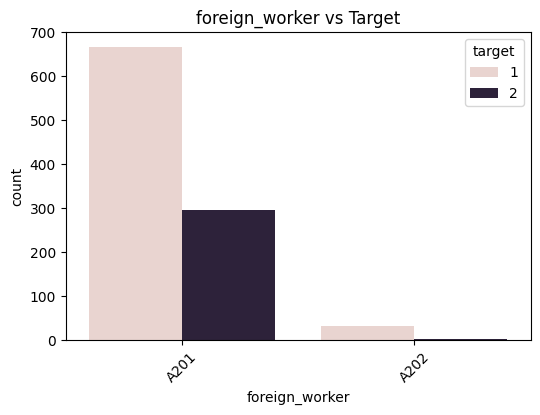

In [25]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='target', data=df)
    plt.title(f"{col} vs Target")
    plt.xticks(rotation=45)
    plt.show()

#Multivariate Analysis

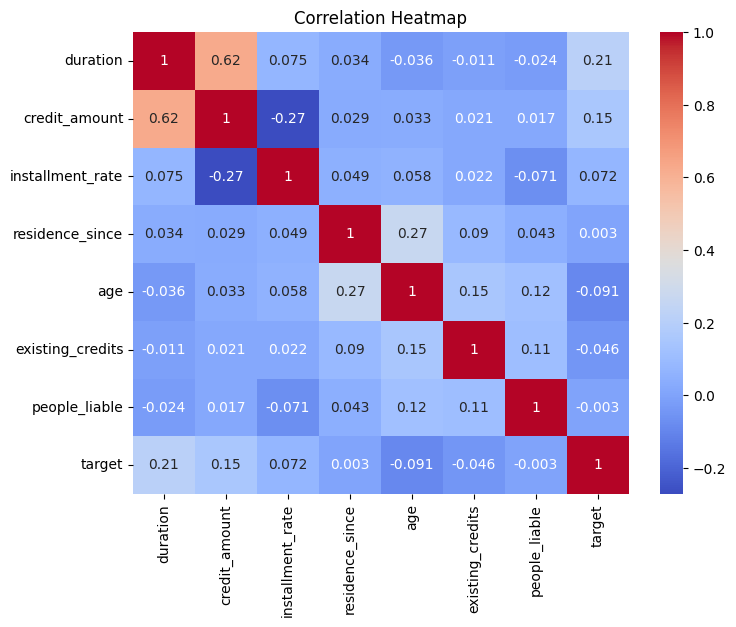

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

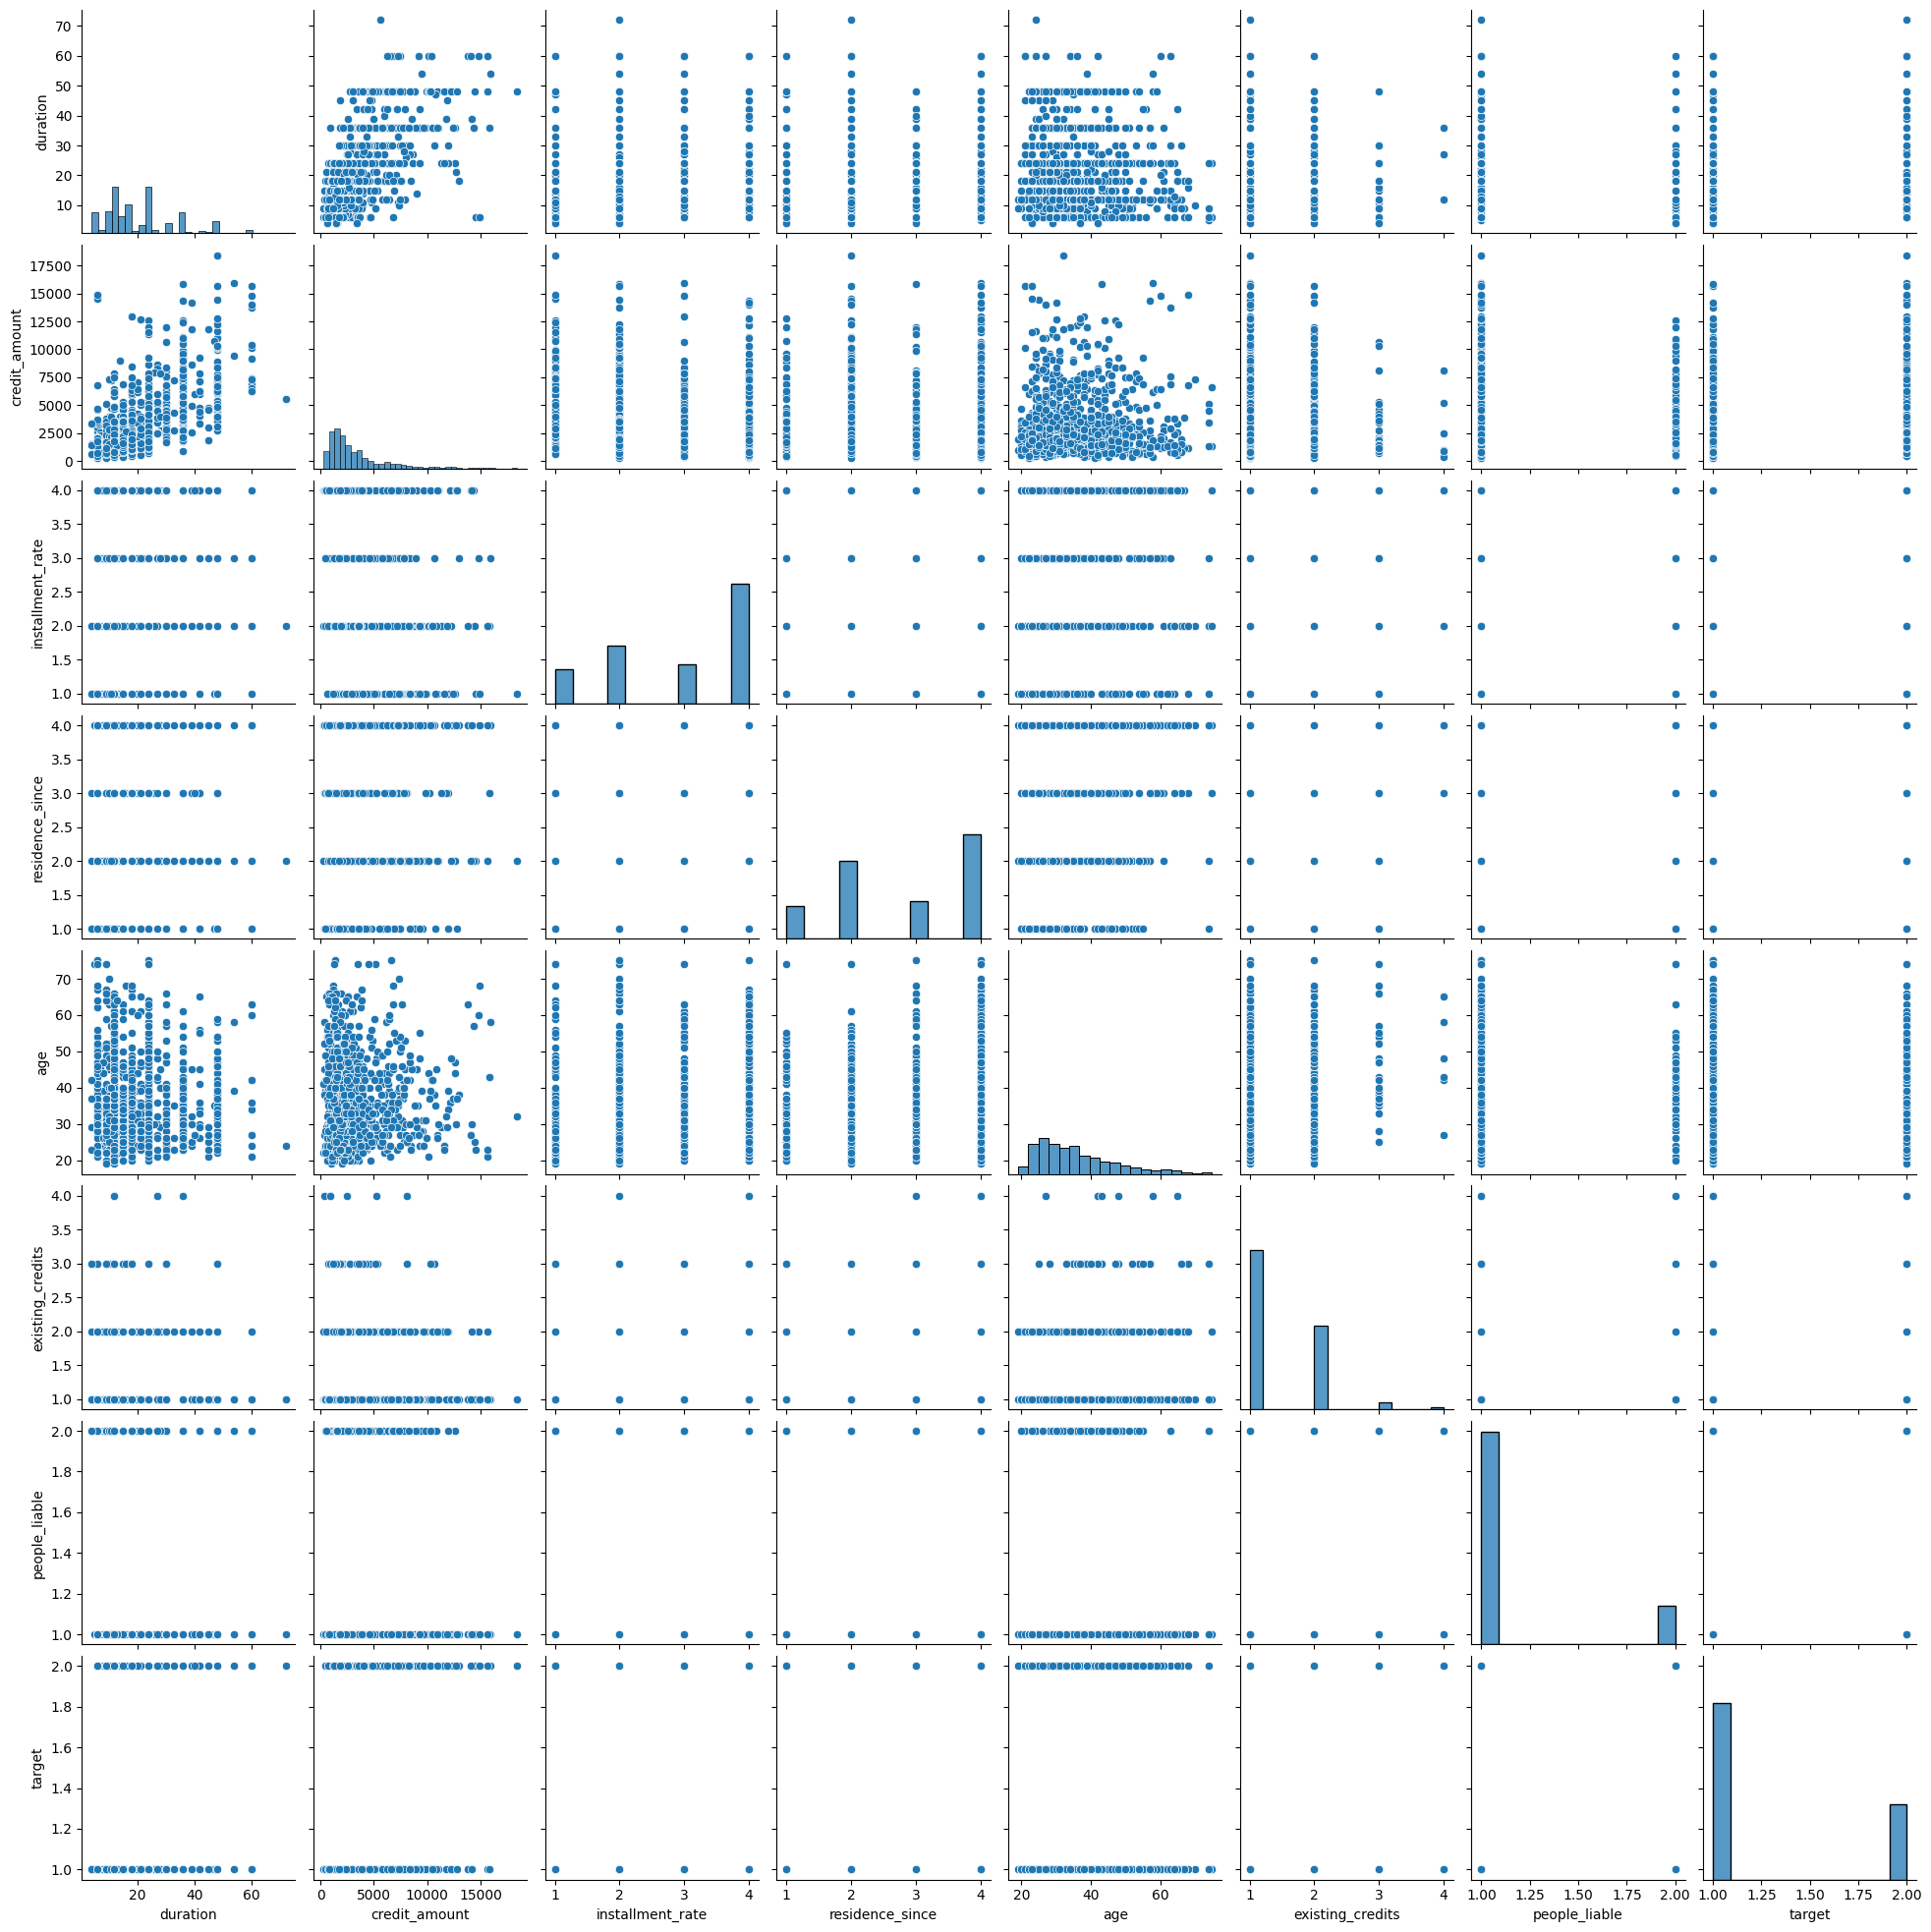

In [27]:
sns.pairplot(df[num_cols])
plt.show()

#Grouping Analysis

In [28]:
ct = pd.crosstab(df['checking_account'], df['target'])
ct

target,1,2
checking_account,,
A11,139,135
A12,164,105
A13,49,14
A14,348,46


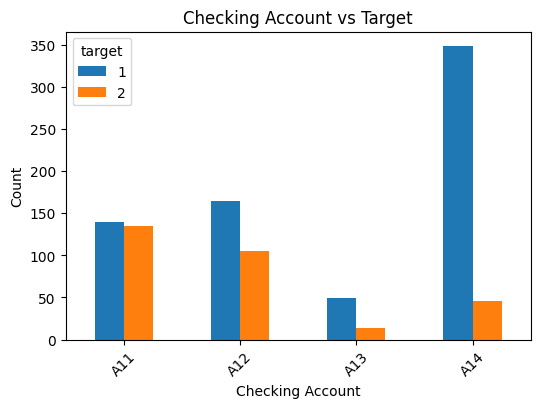

In [29]:
ct.plot(kind='bar', figsize=(6,4))
plt.title("Checking Account vs Target")
plt.xlabel("Checking Account")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

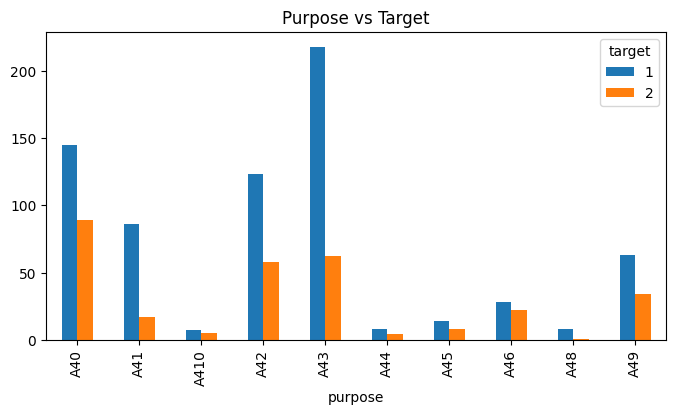

In [30]:
ct3 = pd.crosstab(df['purpose'], df['target'])

ct3.plot(kind='bar', figsize=(8,4))
plt.title("Purpose vs Target")
plt.xticks(rotation=90)
plt.show()

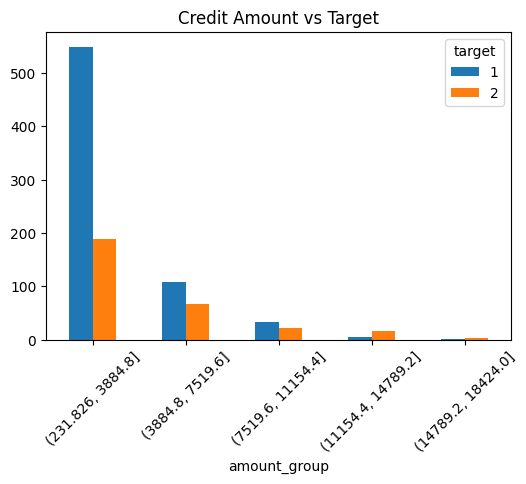

In [31]:
df['amount_group'] = pd.cut(df['credit_amount'], bins=5)

ct4 = pd.crosstab(df['amount_group'], df['target'])

ct4.plot(kind='bar', figsize=(6,4))
plt.title("Credit Amount vs Target")
plt.xticks(rotation=45)
plt.show()

GroupBy and cross-tabulation analysis shows how different categories are distributed across credit risk classes

#Outlier detection

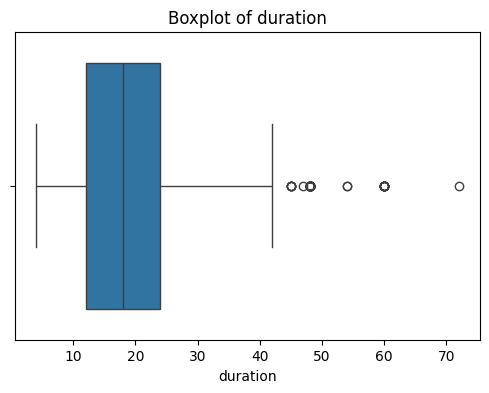

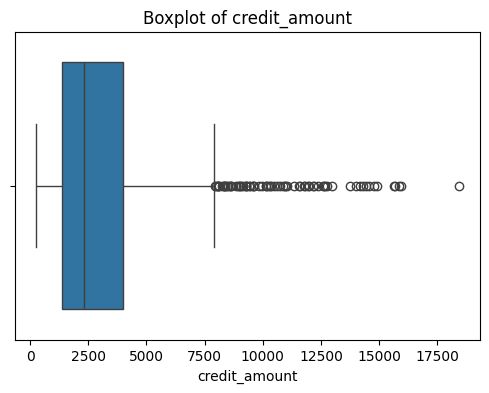

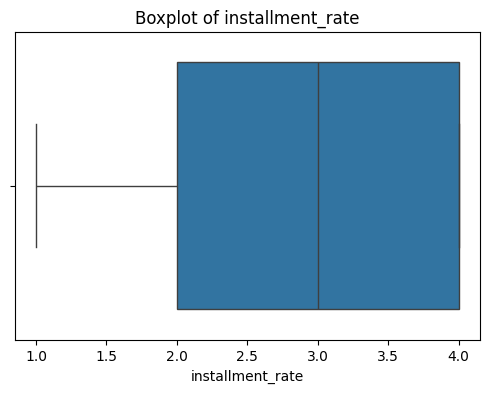

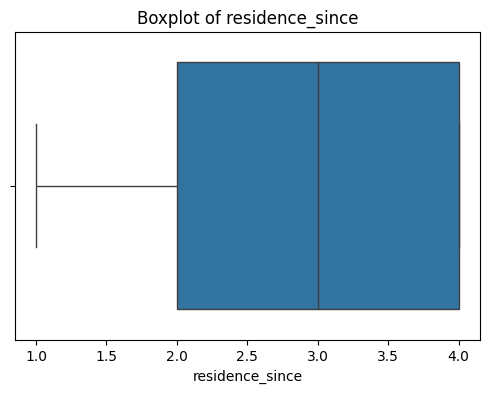

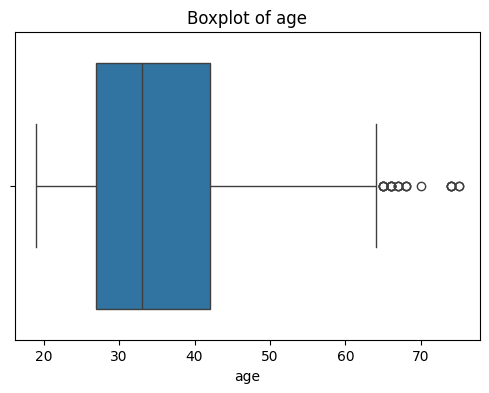

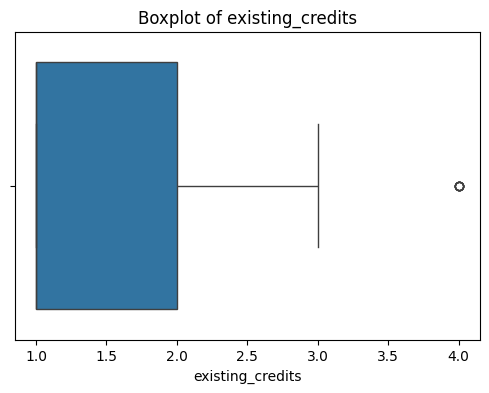

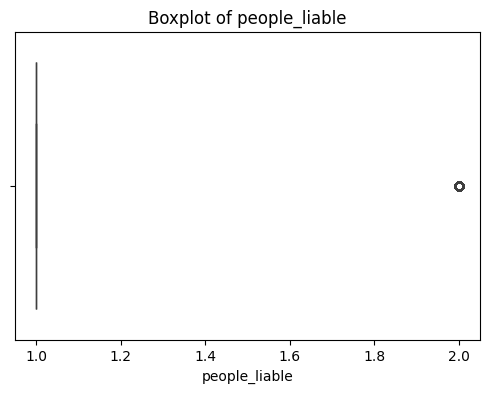

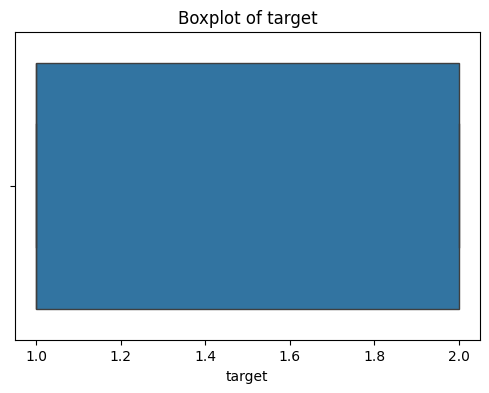

In [32]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [33]:
# Skewness

skewness = df[num_cols].skew()
skewness


,0
duration,1.094184
credit_amount,1.949628
installment_rate,-0.531348
residence_since,-0.272570
age,1.020739
existing_credits,1.272576
people_liable,1.909445
target,0.874183


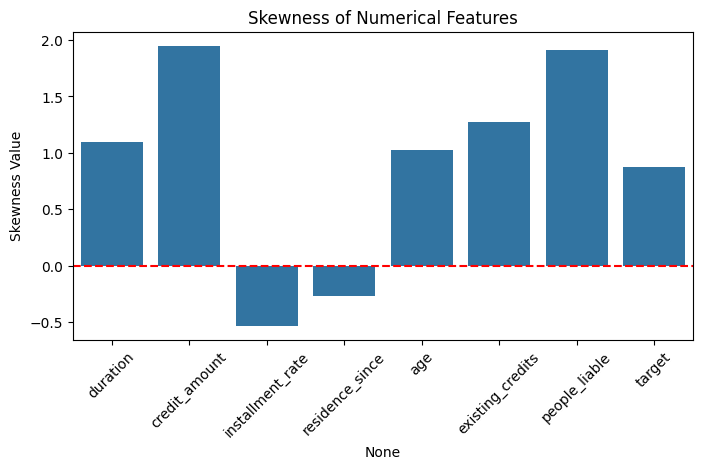

In [34]:
plt.figure(figsize=(8,4))
sns.barplot(x=skewness.index, y=skewness.values)
plt.axhline(0, color='red', linestyle='--')
plt.title("Skewness of Numerical Features")
plt.ylabel("Skewness Value")
plt.xticks(rotation=45)
plt.show()

Interpretation

Skewness > 0 → Right skewed

Skewness < 0 → Left skewed

≈ 0 → Symmetric

In [35]:
# Kurtosis
kurtosis = df[num_cols].kurtosis()
kurtosis

,0
duration,0.919781
credit_amount,4.292590
installment_rate,-1.210473
residence_since,-1.381449
age,0.595780
existing_credits,1.604439
people_liable,1.649274
target,-1.238284


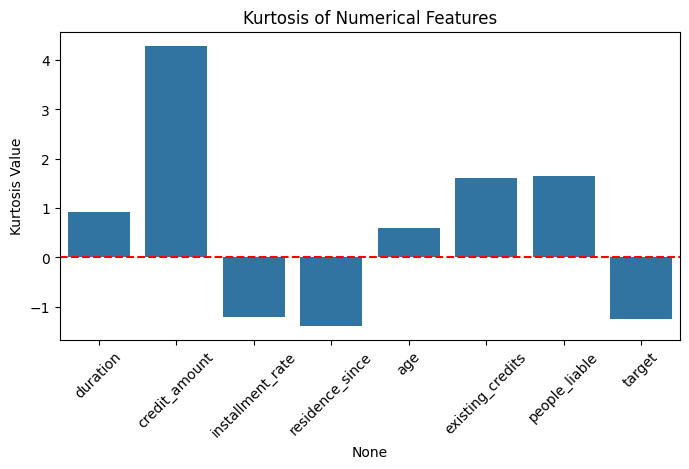

In [36]:
plt.figure(figsize=(8,4))
sns.barplot(x=kurtosis.index, y=kurtosis.values)
plt.axhline(0, color='red', linestyle='--')
plt.title("Kurtosis of Numerical Features")
plt.ylabel("Kurtosis Value")
plt.xticks(rotation=45)
plt.show()

Interpretation

Kurtosis > 0 → Heavy tails (outliers present)

Kurtosis < 0 → Light tails

≈ 0 → Normal distribution

#Insights
Data Quality

The dataset contains no missing values and no duplicate records, indicating good data quality.

Target Distribution

The target variable shows an imbalanced distribution, with more non-risky customers than risky ones.

Numerical Features

Features such as credit amount and duration show high variability, indicating diverse loan conditions.

Some numerical features exhibit skewness, suggesting non-normal distribution of data.

Categorical Features

Categorical variables are represented using encoded values and show uneven distribution across categories.

Certain categories appear more frequently, indicating dominant financial conditions.

Feature vs Target Relationship

Some categorical features, such as checking account and credit history, show noticeable variation in credit risk distribution.

Numerical features like credit amount and duration show differences between risky and non-risky customers.

 Outliers

Numerical features such as credit amount contain potential outliers, which may influence model performance.

Correlation

Moderate correlation exists among numerical features, but no strong multicollinearity is observed.

#Data Preprocessing

## No Null values
## No Duplicates
## No Irregular data formats
## Outliers are kept
Although some numerical features show outliers, they were not removed as tree-based models are robust to outliers. Additionally, removing them could lead to loss of important financial patterns

In [37]:
df["target"]= df["target"].replace({1: 0, 2: 1})

In [38]:
X = df.drop('target', axis=1)
y = df['target']

In [39]:
print(y.unique())

[0 1]


In [40]:
num_cols,cat_cols

(Index(['duration', 'credit_amount', 'installment_rate', 'residence_since',
        'age', 'existing_credits', 'people_liable', 'target'],
       dtype='object'),
 Index(['checking_account', 'credit_history', 'purpose', 'savings',
        'employment', 'personal_status', 'other_debtors', 'property',
        'other_installment_plans', 'housing', 'job', 'telephone',
        'foreign_worker'],
       dtype='object'))

In [41]:
num_cols=[col for col in num_cols if col!="target"]

In [42]:
num_cols

['duration',
 'credit_amount',
 'installment_rate',
 'residence_since',
 'age',
 'existing_credits',
 'people_liable']

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,stratify=y
)

In [44]:
print(y_train.unique())

[1 0]


In [45]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [46]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

#Model Selection

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

#Model Initialization

In [48]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

#Model Training

In [49]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:39:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#Model evaluation

In [50]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import pandas as pd

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, auc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC"])
results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.783333,0.801058
2,XGBoost,0.740000,0.773016
1,Decision Tree,0.653333,0.593651


#visualization

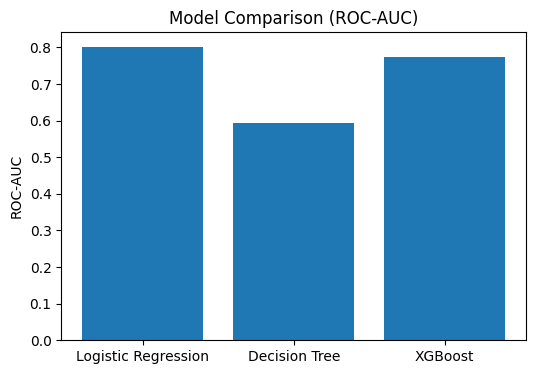

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(results_df["Model"], results_df["ROC-AUC"])
plt.title("Model Comparison (ROC-AUC)")
plt.ylabel("ROC-AUC")
plt.show()

#Best Model

In [52]:
best_model_row = results_df.sort_values(
    by=["ROC-AUC", "Accuracy"],
    ascending=[False, False]
).iloc[0]

best_model_name = best_model_row["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


#Hyperparameter Tuning

In [53]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier

In [54]:
scale_pos_weight = len(y_train[y_train==0])/len(y_train[y_train==1])

In [55]:
len(y_train[y_train==0]),len(y_train[y_train==1])

(490, 210)

In [56]:
scale_pos_weight

2.3333333333333335

In [57]:
xgb=XGBClassifier(eval_metric="logloss",random_state=42,use_label_encoder=False,scale_pos_weight=scale_pos_weight)

In [58]:
param_grid={
    "max_depth":[2,3,4],
    "learning_rate":[0.01,0.05],
    "n_estimators":[50,100,150],
    "subsample":[0.7,0.8],
    "colsample_bytree":[0.7,0.8],
    "gamma":[0.1,0.2,0.3],
    "reg_alpha":[0,0.1,0.5],
    "reg_lambda":[1,2,5]
}

In [59]:
cv=StratifiedKFold(n_splits=10,
                   shuffle=True,
                   random_state=42)

In [60]:
grid=GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

In [61]:
grid.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:51:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8],
                         'gamma': [0.1, 0.2, 0.3],
                         'learning_rate': [0.01, 0.05], 'max_depth': [2, 3, 4],
                         'n_estimators': [50, 100, 150],
                         'reg_alpha': [0, 0.1, 0.5], 'reg_lambda': [1, 2, 5],
                         'subsample': [0.7, 0.8]},
             scoring='roc_auc')

In [62]:
print("Best Parameters:",grid.best_params_)
print("Best Score:",grid.best_score_)

Best Parameters: {'colsample_bytree': 0.7, 'gamma': 0.2, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 150, 'reg_alpha': 0.1, 'reg_lambda': 5, 'subsample': 0.8}
Best Score: 0.7913022351797862


In [63]:
best_xgb = grid.best_estimator_

best_xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:51:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [64]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7266666666666667
ROC-AUC: 0.7912169312169313


#Phase2

#Model Selection

In [65]:
optimized_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        colsample_bytree=0.8,
        gamma=0,
        learning_rate=0.01,
        max_depth=3,
        n_estimators=200,
        subsample=0.8
    )
}

In [66]:
trained_opt_models = {}

for name, model in optimized_models.items():
    model.fit(X_train, y_train)
    trained_opt_models[name] = model

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:51:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [67]:
from sklearn.metrics import accuracy_score, roc_auc_score
results_opt = []

for name, model in trained_opt_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results_opt.append([name, acc, auc])

results_opt_df = pd.DataFrame(results_opt, columns=["Model", "Accuracy", "ROC-AUC"])
results_opt_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.783333,0.801058
2,XGBoost,0.726667,0.765503
1,Decision Tree,0.653333,0.593651


After applying hyperparameter tuning and stratified cross-validation, the performance of XGBoost did not show a significant improvement compared to the baseline. This indicates that the default parameters were already near optimal for this dataset, and the dataset’s relatively simple structure limits the advantage of more complex models

This experiment demonstrates that model performance depends on the nature of the dataset, and simpler models like Logistic Regression can perform competitively or even better on structured datasets with limited complexity

Logistic Regression performs well because it is effective for linear relationships and smaller datasets. Since the German Credit dataset is structured and not highly complex, Logistic Regression is able to capture the underlying patterns efficiently

Although Logistic Regression achieved slightly higher ROC-AUC, XGBoost was selected for further analysis using SHAP because it is a more complex model, and interpretability is more critical for such models.”

In [68]:
user_input = {
    "duration": 12,
    "credit_amount": 7000,
    "installment_rate": 2,
    "residence_since": 3,
    "age": 35,
    "existing_credits": 1,
    "people_liable": 1,

    "checking_account": "A13",
    "credit_history": "A34",
    "purpose": "A43",
    "savings": "A61",
    "employment": "A72",
    "personal_status": "A93",
    "other_debtors": "A101",
    "property": "A121",
    "other_installment_plans": "A141",
    "housing": "A152",
    "job": "A173",
    "telephone": "A191",
    "foreign_worker": "A201"
}

#prediction

In [69]:
user_df = pd.DataFrame([user_input])

In [70]:
user_processed = preprocessor.transform(user_df)

In [71]:
prediction = best_model.predict(user_processed)
probability = best_model.predict_proba(user_processed)

print("Prediction:", prediction[0])
print("Probability:", probability[0])

Prediction: 0
Probability: [0.81090897 0.18909103]


In [72]:
# Train performance
y_train_pred = model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Train ROC:", roc_auc_score(y_train, model.predict_proba(X_train)[:,1]))

# Test performance
y_test_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test ROC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

Train Accuracy: 0.7914285714285715
Train ROC: 0.8825072886297376
Test Accuracy: 0.7266666666666667
Test ROC: 0.7655026455026455


#SHAP

In [73]:
!pip install shap

In [74]:
import shap

In [75]:
# Recreate raw data for SHAP (without affecting trained model)

X_raw = df.drop("target", axis=1)
y_raw = df["target"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42
)

In [76]:
X_train_processed = preprocessor.transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

In [77]:
import numpy as np
X_train_processed = np.array(X_train_processed)
X_test_processed = np.array(X_test_processed)

In [78]:
feature_names = preprocessor.get_feature_names_out()

In [79]:
explainer = shap.TreeExplainer(best_xgb)

In [80]:
shap_values = explainer.shap_values(X_test_processed[:100])

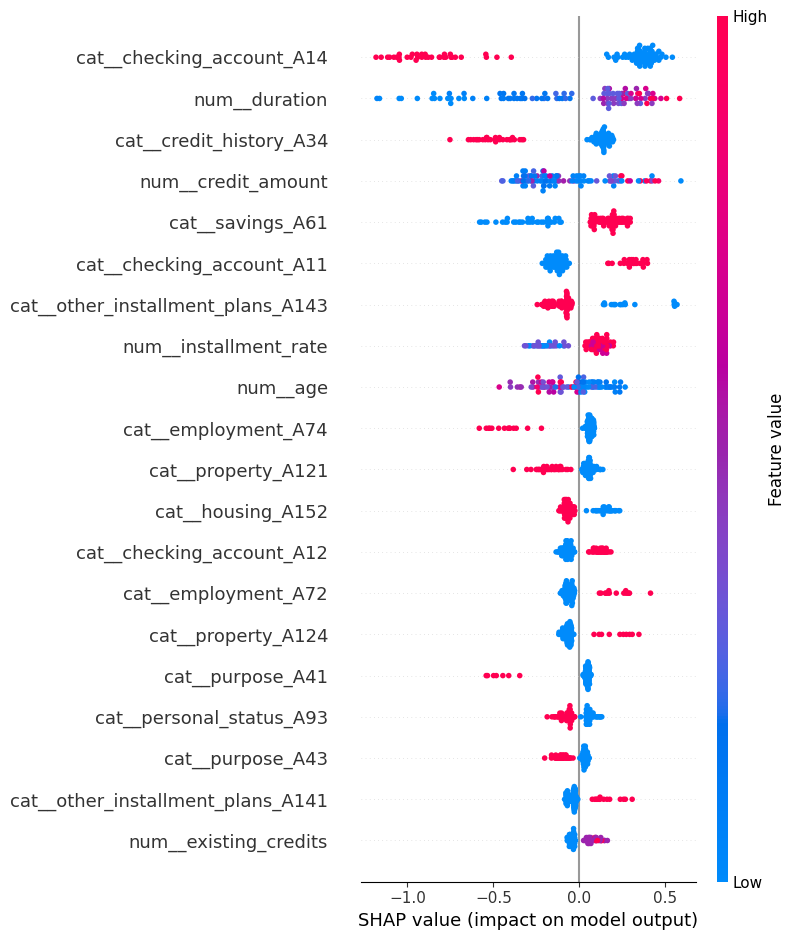

In [81]:
shap.summary_plot(shap_values, X_test_processed[:100], feature_names=feature_names)

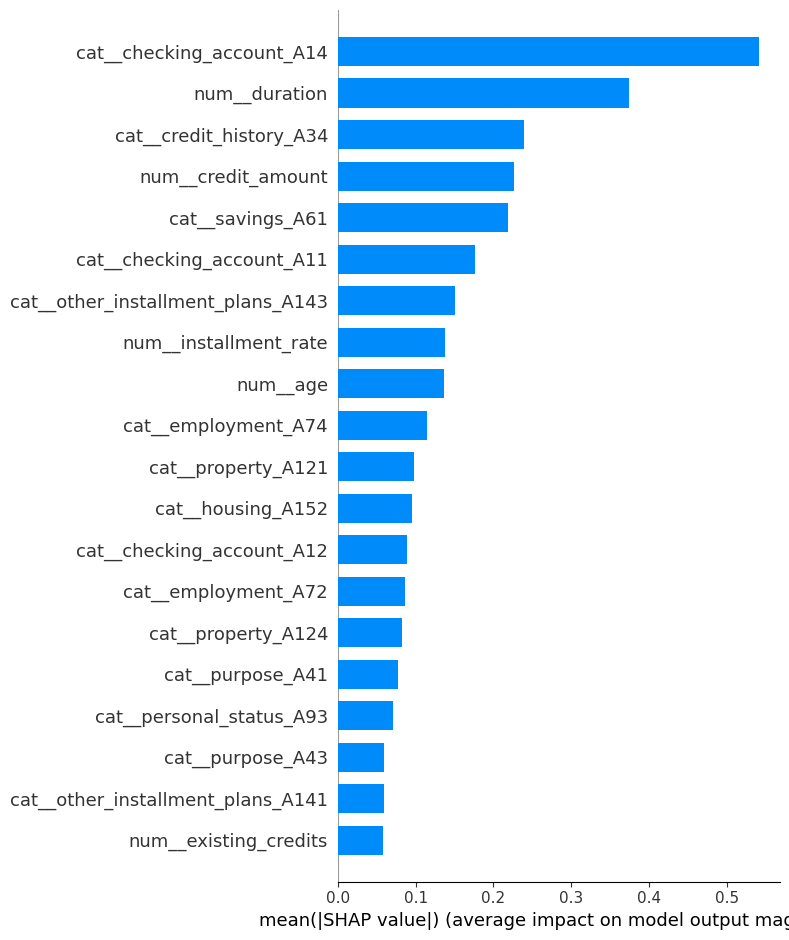

In [82]:
shap.summary_plot(shap_values, X_test_processed[:100], feature_names=feature_names, plot_type="bar")

In [83]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test_processed[0], feature_names=feature_names)

SHAP helps us understand how each feature contributes to the prediction. The summary plot shows the most important features affecting credit risk classification.

Even though XGBoost is a complex model, SHAP provides interpretability by assigning contribution values to each feature, making the model explainable.

Raw data is recreated for SHAP analysis because the preprocessor requires original feature format.
This does not affect the trained model and is only used for interpretability.